<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# some initialization stuff
%run ../init.py
%matplotlib inline

import nns.helpers as hp

<IPython.core.display.Latex object>

# Graphs

- Data in many domains can be represented as a graph
- NNs considered so far utilized specific layers to extract features from data with temporal and/or spatial relations

## Convolutional Networks 

- Applications of CNNs to image analysis are a good example of extracting features from data with *spatial* relations - 2D or 3D grids
- NLP or speech recognition represent analysis of *temporal* relations - 1D grid 
- Conv layers can solve high-dimensional learning problems due to local view:
    - MNIST training set: 60000 samples with $28\times 28 \times 1 \text{ pixels } =  47 \cdot 10^6$ data points
    - ImageNet training set: $14 \cdot 10^6$ samples with avg. $469 \times 387 \times 3$ pixels $ \approx 8 \cdot 10^{12}$ data points
- Main assumption: the data comprises patterns (compositional) that are:
  - *Local*: close proximity in time and/or space
  - *Stationary*: shared by many samples of the domain
  - *Hierarchical*: more complex patterns can be constructed from simple ones, like edges form objects 

## Graph representation

- In many domains relations are neither temporal nor spatial
  - Social networks
  - Product configuration and manufacturing
  - Chemistry - structure of molecules
  - Medicine - genome data, relations between drugs, patients, procedures, and treatment protocols
  - Transportation networks
  - Knowledge graphs - relations between concepts (n-grams denoting them) 
  - Computer graphics - synthesis of 3D models (meshes)

### Example: Social networks
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/graphs-ex.svg" width="60%"/>
</center>

## Graph definition

- A graph is a triple $\mathcal{G}=(\st{V},\st{E}, \vec{A})$
  - $\st{V} = \{1,\dots,n\}$ is a set of *vertices*, and 
  - $\st{E} = \{\dots, ij, \dots\} \subseteq \st{V}\times \st{V}$ is a set of *edges* between pairs of vertices
  - $\vec{A}$ is an *adjacency matrix* - a square $n\times n$ matrix $A$, where $a_{ij} = 1$ if $i,j \in \st{E}$ , and $0$ otherwise
  
  
- Graphs may be augmented with different features:
  - Nodes: vector $\vec{v}_i=[name, surname, \dots]^\top \in \mathbb{R}^{d_v}$
  - Edges: vector $\vec{e}_{ij}=[relation, interests, \dots]^\top \in \mathbb{R}^{d_e}$
  - Graph: $\vec{g} = [organization, location, \dots]^\top \in \mathbb{R}^{d_g}$ 
  
  
- An adjacency matrix provides much data about a graph, e.g.:
  - $\vec{A}$ is symmetric if a graph is undirected, i.e., all edges are bi-directional 
  - $\vec{A}$ of an empty graph is a zero matrix
  - $\vec{A}^n$ comprises all path of the length $n$

### Example: Social networks, cont'd
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/graphs-adj.svg" width="50%"/>
</center>

## Convolutional layers

- *Traditional* convolutional layer:
$$\vec{M} = b + \vec{W}*\vec{H}$$
where $*$ denotes the convolution operation and
  - $\vec{b}$ is scalar denoting *bias*,  
  - $\vec{W}$ is a $n \times m$ *kernel*, 
  - $\vec{H}$ is a $x_1 \times y_1 \times d$ *input matrix*, and
  - $\vec{M}$ is a $x_2 \times y_2 \times d$ *activation map*
- The convolution operation is defined as a sum of products:
$$\vec{M}_{ij} = b + \sum_{m=-\infty}^\infty\sum_{n=-\infty}^\infty w_{n,m}h_{i-m,j-n}$$
- Computation is in $O(n)$ and can easily be parallelized
- All nodes are ordered and are always in the same position - template/pattern matching

<center>
    Kernel coordinates <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/graphs-conv.svg" width="20%"/>
</center>


## Convolutions for graphs

- **Main issue**: there is no node ordering!
  - No matter how we position the vertices in space, the structure of the graph is preserved
  - Indices of nodes of different graphs must not always match, although both graphs describe elements from the same domain
  - Neighborhood of vertices for kernel matching might be different, i.e., a vertex can be adjacent to many other vertices, not like pixels in an image

<center>
  <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/graphs-temp.svg" width="60%"/>
</center>

# Basic notions

- **Idea**: design template matching which is invariant to node permutations (re-parametrization)
-  *Permutation invariance* $f(\vec{PV}) = f(\vec{V})$, e.g., summation, averaging, maximization, or minimization applied to a set of elements are permutation invariant
    - $\vec{V} = [\vec{v}_1, \dots, \vec{v}_n]^\top$ is a vertex feature matrix, where $i$th row comprises feature observations for a vertex $i$
    - $\vec{P}$ is a permutation matrix, a binary square matrix that has exactly one $1$ in each row and all other elements are $0$
    - A product $\vec{PV}$ changes the order of rows and $\vec{VP}$ of columns
- *Permutation equivariance* $f(\vec{PV}) = \vec{P}f(\vec{V})$ - functions that do not change the order of the nodes

## Learning on sets

- Equivariance implies that application of $f$ does not change the order of rows
  - Use equivariant set functions to transform each node $\vec{v}_i$ into a latent vector $\vec{h}_i$, i.e., $\vec{h}_i = f(\vec{v}_i)$ 
  - Similarly, $\vec{H} = f(\vec{V})$, i.e., $f$ can be thought like applied row-wise
- Stacking equivariant functions
$$f(\vec{V})=\phi\left(\oplus_{i \in \st{V}} f(\vec{v}_i)\right)$$
where $\oplus$ is some permutation invariant aggregation function, like sum or max, and $\phi$ is some equivariant transformation function

## Learning on graphs

- However, sets of nodes is not enough, since there are also edges in the graphs
- Permutations on nodes must also be applied to edges, i.e., the adjacency matrix
  - Invariance $f(\vec{PV},\vec{PAP}^\top) = f(\vec{V}, \vec{A})$
  - Equivariance $f(\vec{PV},\vec{PAP}^\top) = \vec{P}f(\vec{V}, \vec{A})$
- Edges of a node define its *neighborhood* (1-hop in this case)
$$\st{N}_i = \{j \mid ij \in \st{E} \lor ji \in \st{E} \}$$
- Hence, we can define a *multiset* of features in the neighborhood of a vertex
$$\vec{V}_{\st{N}_i} = \{ \vec{v_j} \in \vec{V} \mid j \in \st{N}_i \}$$
which can be provided to a local function $\vec{h}_i = g(\vec{v}_i,\vec{V}_{\st{N}_i})$ operating on a neighborhood of $\vec{v}_i$
- $g$ must be *permutation invariant* wrt. $\vec{V}_{\st{N}_i}$ to provide the latent features of $\vec{v}_i$
  - Summarize features of the node and its neighbors in one vector $\vec{h}_i$

## Learning on graphs, cont'd

- Permutation equivariant function for graphs $f(\vec{V}, \vec{A})$ can be defined as applying the local function $g(\vec{v}_i,\vec{V}_{\st{N}_i})$ over all neighborhoods
$$f(\vec{V}, \vec{A}) = \begin{bmatrix}
g(\vec{v}_1,\vec{V}_{\st{N}_1}) \\
\dots \\
g(\vec{v}_n,\vec{V}_{\st{N}_n})
\end{bmatrix}$$
- The function $g$ is referred in the literature as diffusion, propagation, or *message passing*
- Definition of $g$ is an active area of research
- $g$ corresponds to GNN layers

<center>
  <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/graphs-tasks.svg" width="100%"/>
</center>

# GNN spatial flavors

<center>
  <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/graphs-flavs.svg" width="100%"/>
</center>

## Convolutional GNNs

$$\vec{h}_i
=g(\vec{v}_i,\oplus_{j\in\st{N}_i}\color{blue}{c_{ij}}\psi(\vec{v}_j))$$
- Features of the neighbor nodes $\psi(\vec{v}_j)$ are aggregated with weights $c_{ij}$
- These weights depend in many cases on adjacency matrix $\vec{A}$
- $\oplus$ is quite often a *sum* of weighted features
- Examples:
  - [Chebyshev Network](https://arxiv.org/abs/1606.09375)
  - [Graph Convolutional Network](https://arxiv.org/abs/1609.02907)
  - [Simple Graph Convolutional Network](https://arxiv.org/abs/1902.07153)
- Convolutional GNNs can be *scaled up* to very large graphs
- Shown to be useful for graphs in which similar nodes tend to be adjacent - *homophilous graphs*
  - E.g., users of a social network or concepts in Wikipedia

## Attentional GNNs

$$\vec{h}_i=g(\vec{v}_i,\oplus_{j\in\mathcal{N}_i}\color{blue}{a(\vec{v}_i,\vec{v}_j)}\psi(\vec{v}_j))$$

- Features of the neighbor nodes $\psi(\vec{v}_j)$ are aggregated with *implicit* weights $\alpha_{ij}=a(\vec{v}_i,\vec{v}_j)$
    - Edges are no longer limited to simple similarity coefficient, like in the convolutional GNNs
    - In attention networks they might also indicate repulsion of the two vertices
    - The function $a(\vec{v}_i,\vec{v}_j)$ implements the [attention mechanism](https://d2l.ai/chapter_attention-mechanisms/index.html) and is learned during training
    - The function $a$ can be non-linear, so the output value $\alpha_{ij}$ can change dramatically depending on the features of the nodes
- Examples:
  - [Mixture Model Network](https://arxiv.org/abs/1611.08402)
  - [Graph Attention Network](https://arxiv.org/abs/1710.10903)
  - [Gated Attention Network](https://arxiv.org/abs/1803.07294)
- Attention adds additional computations $\Rightarrow$ scale not so well as convolutional GNNs

## Message passing GNNs

$$\vec{h}_i=g(\vec{v}_i,\oplus_{j\in\mathcal{N}_i}\color{blue}{\psi(\vec{v}_i,\vec{v}_j)})$$

- Message passing GNNs are the most expressive from the three types
  - Applications in chemistry, physics, pharmacy, etc. 
- Compute arbitrary vectors (messages) $\vec{m}_{ij} = \psi(\vec{v}_i,\vec{v}_j)$ that are sent along the edges
    - In attention GNNs we use raw node features weighted by a constant computed from them
    - $\vec{m}_{ij}$ represent a synthetic set of features created out of the features of the two nodes
- Examples:
  - [Interaction Networks](https://arxiv.org/abs/1612.00222)
  - [Message Passing Neural Networks](https://arxiv.org/abs/1704.01212)
  - [Graph network](https://arxiv.org/abs/1806.01261)
- Computation of messages might be hard $\Rightarrow$ scalability issues

## Example: Zachary's karate club

- [Zachary's karate club](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) is a small social network with 34 members
    - Network was studied in the 1970-72 by Wayne W. Zachary documenting communication between members outside of the club
    - As a conflict between an administrator and an instructor arose, the club split into 4 groups
    - The original paper studied the social behavior of the members trying to understand how communication outside of the club influenced them to choose a group to join after the club dissolution

In [2]:
from torch_geometric.datasets import KarateClub

ds = KarateClub()
print(f'Graphs: {len(ds)} with {ds.num_classes} classes')

g = ds[0]
print(f'Features (node/edge): {g.num_features} ({g.num_node_features}/{g.num_edge_features})')
print(f'Undirected: {g.is_undirected()}')
print(f'Isolated nodes: {g.has_isolated_nodes()}')
print(f'Self-loops: {g.has_self_loops()}')

Graphs: 1 with 4 classes
Features (node/edge): 34 (34/0)
Undirected: True
Isolated nodes: False
Self-loops: False


In [3]:
print(f'Data fields: {g.keys}\n{g}\n')
print(f'Node features (one-hot encoded node indexes):\n{g.x}')
print(f'Classes: {g.y}')
print(f'Edges: {g.edge_index[:,12:18].T}')

Data fields: <bound method BaseData.keys of Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])>
Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])

Node features (one-hot encoded node indexes):
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Classes: tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])
Edges: tensor([[ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2]])


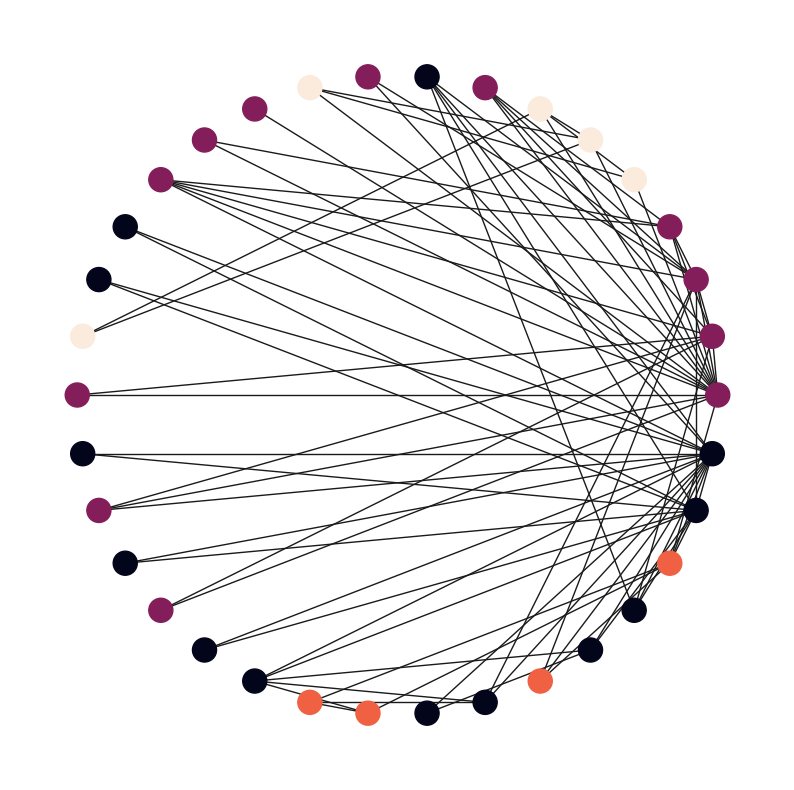

In [4]:
hp.plot_graph(g, classes=g.y)

- Since we are similar members of a networks are connected to each other, we can use a Graph Convolutional Network (GCN)
- GNN operator suggested in GCN is quite simple
$$\vec{h}_i^{(l+1)} = \vec{W}^{(l+1)} \sum_{j\in\st{N}_i\cup\{i\}} \frac{1}{c_{ji}}\vec{h}_j^{(l)}$$
where 
  - $c_{ji}$ is a normalization coefficient of an edge and 
  - $\vec{W}^{(l+1)}$ is an $n\times m$ trainable set of weights of a layer of shape with $n$ and $m$ are the numbers of output and input features, resp.
- PyG implements this operator in GCNConv layer

In [5]:
from torch_geometric.nn import GCNConv
torch.manual_seed(2)

class GCN(torch.nn.Module):
    def __init__(self, ds):
        super().__init__()
        self.gcn1 = GCNConv(ds.num_features, 8)     # 34 -> 8
        self.gcn2 = GCNConv(8, 4)                   # 8 -> 4
        self.gcn3 = GCNConv(4, 2)                   # 4 -> 2
        self.fc = torch.nn.Linear(2, ds.num_classes)          # 2 -> 4 classes

    def forward(self, x, edge_index):
        # Extract features with 3 tahn activated GCN layers
        # This corresponds to looking at a 3-hop neighborhood
        h = torch.tanh(self.gcn1(x, edge_index))
        h = torch.tanh(self.gcn2(h, edge_index))
        h = torch.tanh(self.gcn3(h, edge_index))
        
        # Classification with a linear layer
        out = self.fc(h)

        return out, h

model = GCN(ds)
print(model)

GCN(
  (gcn1): GCNConv(34, 8)
  (gcn2): GCNConv(8, 4)
  (gcn3): GCNConv(4, 2)
  (fc): Linear(in_features=2, out_features=4, bias=True)
)


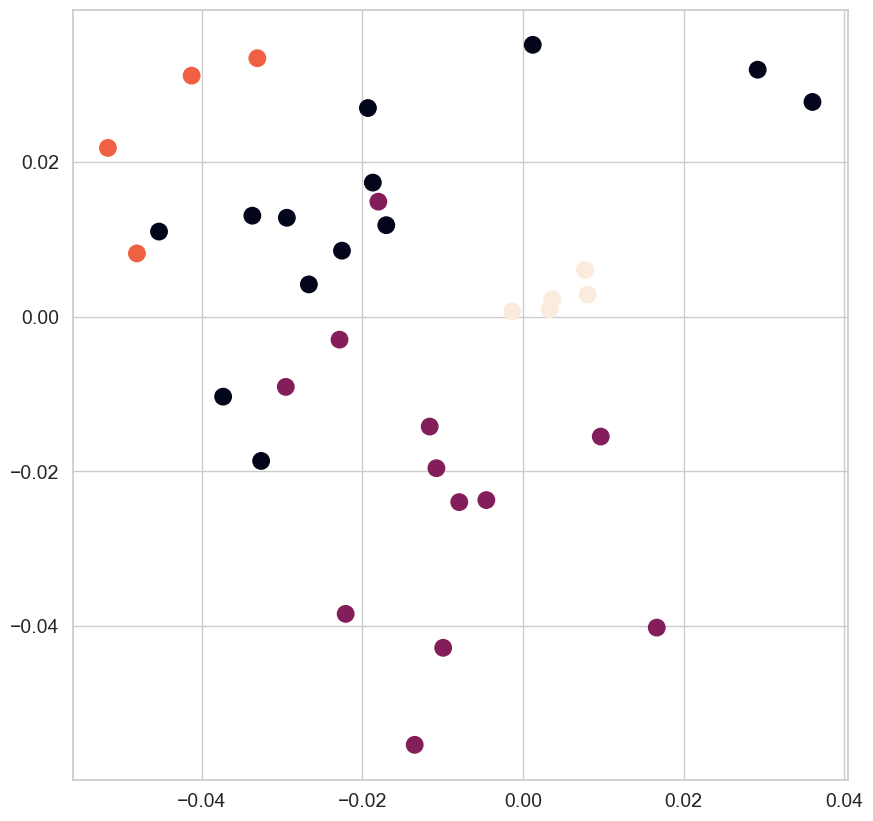

tensor([[0.2078, 0.3159, 0.3212, 0.1551],
        [0.2115, 0.3125, 0.3202, 0.1558],
        [0.2018, 0.3202, 0.3238, 0.1542],
        [0.2053, 0.3137, 0.3251, 0.1559],
        [0.2006, 0.3152, 0.3285, 0.1557]])


In [6]:
# Visualization of latent space obtained by an untrained network
model.eval()
with torch.no_grad():
    out, h = model(g.x, g.edge_index)
    hp.plot_embedding(h, classes=g.y)
    print(torch.softmax(out, dim=1)[0:5,:])

In [7]:
torch.manual_seed(2)
ce_loss = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
train_mask = torch.randint(0, 2, g.y.shape, dtype=torch.bool)
print(f'Training using {train_mask.sum()} examples')

def train(g):
    opt.zero_grad()
    out, h = model(g.x, g.edge_index)
    loss = ce_loss(out[train_mask], g.y[train_mask])
    loss.backward()
    opt.step()
    return loss, h

def epoch(n, sc, classes, title):
    loss, h = train(g)
    # image output
    t = h.detach().cpu().numpy()
    sc.set_offsets(t)
    sc.set_array(classes)
    sc.set_sizes([150]*t.shape[0])
    title.set_text(f'Epoch: {n}, Loss: {loss.item():.4f}')
    return sc,

Training using 19 examples


In [8]:
from matplotlib import animation

model.train()
def animate(classes):
    fig, ax = plt.subplots(figsize=(10,10))
    fig_title = fig.suptitle('')
    sc = ax.scatter(classes, classes, s=150, c=classes)
    ax.axis([-2, 2, -2, 2])

    return animation.FuncAnimation(fig, epoch, fargs=(sc, classes, fig_title), frames=600, 
                                   interval=30, blit=True);

display(HTML(animate(classes=g.y).to_html5_video()))
plt.close()

In [9]:
model.eval()
test_mask = ~train_mask
with torch.no_grad():
    out, _ = model(g.x, g.edge_index)
    test_correct = out.argmax(dim=1)[test_mask] == g.y[test_mask]
    
    print("Predictions for the first five nodes in the test set\n", torch.softmax(out[test_mask], dim=1)[0:5,:])
    print(f'Test accuracy: {int(test_correct.sum()) / int(test_mask.sum())}')

Predictions for the first five nodes in the test set
 tensor([[7.3868e-04, 9.9510e-01, 1.7785e-05, 4.1441e-03],
        [7.1911e-04, 9.9572e-01, 1.5105e-05, 3.5461e-03],
        [6.7988e-05, 3.1961e-03, 2.5205e-02, 9.7153e-01],
        [6.1415e-05, 2.7979e-03, 2.5552e-02, 9.7159e-01],
        [9.8899e-01, 7.4513e-03, 3.5430e-03, 1.2545e-05]])
Test accuracy: 1.0


### Resources

- GAT - Graph Attention Networks in [Pytorch](https://github.com/gordicaleksa/pytorch-GAT)
- PyG - [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) a framework implementing many graph [operators](https://pytorch-geometric.readthedocs.io/en/latest/notes/cheatsheet.html), layers, and training methods
- A comprehensive [tutorial](https://github.com/AntonioLonga/PytorchGeometricTutorial) on PyG